https://365datascience.com/tutorials/python-tutorials/pca-k-means/

In [1]:
# Load general libraries
import numpy as np
import pandas as pd
#pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import plotly.express as px
import plotly.graph_objs as go
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score

## Data load

In [2]:
nuclei = pd.read_csv('/app/data/cellprofiler_segmentation/watershed_nuclei.txt', sep='\t', index_col = 1)
membrane = pd.read_csv('/app/data/cellprofiler_segmentation/object_membrane.txt', sep='\t', index_col = 1)
cytoplasm = pd.read_csv('/app/data/cellprofiler_segmentation/filtered_segmented_cytoplasm.txt', sep='\t', index_col = 1)

In [3]:
col = nuclei.pop('Children_filtered_segmented_cytoplasm_Count')
nuclei.insert(0, 'Children_filtered_segmented_cytoplasm_Count', col)
display(nuclei)

,Children_filtered_segmented_cytoplasm_Count,ImageNumber,AreaShape_BoundingBoxMaximum_X,AreaShape_BoundingBoxMaximum_Y,AreaShape_BoundingBoxMaximum_Z,AreaShape_BoundingBoxMinimum_X,AreaShape_BoundingBoxMinimum_Y,AreaShape_BoundingBoxMinimum_Z,AreaShape_BoundingBoxVolume,AreaShape_Center_X,AreaShape_Center_Y,AreaShape_Center_Z,AreaShape_EquivalentDiameter,AreaShape_EulerNumber,AreaShape_Extent,AreaShape_MajorAxisLength,AreaShape_MinorAxisLength,AreaShape_SurfaceArea,AreaShape_Volume,Location_Center_X,Location_Center_Y,Location_Center_Z,Number_Object_Number
ObjectNumber,,,,,,,,,,,,,,,,,,,,,,,
1,1,1,174,16,4,146,0,0,1792,157.801205,4.971888,0.554217,9.834303,0,0.277902,28.236047,14.801025,378.552704,498,157.801205,4.971888,0.554217,1
2,1,1,208,43,10,174,0,0,14620,192.135186,18.481298,4.224152,24.270780,0,0.512038,49.625393,26.442739,1480.238281,7486,192.135186,18.481298,4.224152,2
3,4,1,61,59,10,0,7,0,31720,26.715728,31.620971,2.639391,22.092630,-1,0.177995,82.046252,35.357546,3068.510742,5646,26.715728,31.620971,2.639391,3
4,1,1,90,84,8,69,64,0,3360,78.995565,74.631929,3.494457,9.514646,1,0.134226,24.445469,13.891595,651.103027,451,78.995565,74.631929,3.494457,4
5,1,1,200,108,3,182,86,0,1188,191.513725,97.454902,0.605882,9.912667,1,0.429293,24.723139,15.361054,390.437103,510,191.513725,97.454902,0.605882,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
472,1,1,1405,1898,10,1402,1895,9,9,1402.833333,1895.833333,9.000000,2.254503,1,0.666667,3.887301,2.309401,13.988679,6,1402.833333,1895.833333,9.000000,472
473,0,1,1221,2450,10,1218,2447,9,9,1218.666667,2448.333333,9.000000,2.254503,1,0.666667,4.216370,2.108185,14.585056,6,1218.666667,2448.333333,9.000000,473
474,1,1,1515,2476,10,1512,2474,9,6,1513.200000,2474.400000,9.000000,2.121569,1,0.833333,3.577709,1.788854,12.353006,5,1513.200000,2474.400000,9.000000,474


In [4]:
col = cytoplasm.pop('Parent_watershed_nuclei')
cytoplasm.insert(0, 'Parent_watershed_nuclei', col)
display(cytoplasm)

,Parent_watershed_nuclei,ImageNumber,AreaShape_BoundingBoxMaximum_X,AreaShape_BoundingBoxMaximum_Y,AreaShape_BoundingBoxMaximum_Z,AreaShape_BoundingBoxMinimum_X,AreaShape_BoundingBoxMinimum_Y,AreaShape_BoundingBoxMinimum_Z,AreaShape_BoundingBoxVolume,AreaShape_Center_X,AreaShape_Center_Y,AreaShape_Center_Z,AreaShape_EquivalentDiameter,AreaShape_EulerNumber,AreaShape_Extent,AreaShape_MajorAxisLength,AreaShape_MinorAxisLength,AreaShape_SurfaceArea,AreaShape_Volume,Location_Center_X,Location_Center_Y,Location_Center_Z,Number_Object_Number,Parent_segmented_cytoplasm
ObjectNumber,,,,,,,,,,,,,,,,,,,,,,,,
1,3,1,39,45,10,0,0,0,17550,14.831743,20.103308,4.149482,26.599368,1,0.561481,56.816560,38.431274,1874.890869,9854,14.831743,20.103308,4.149482,1,1
2,3,1,68,39,10,23,0,0,17550,45.546510,16.311951,4.372377,23.411829,0,0.382849,53.048634,28.615474,1606.489502,6719,45.546510,16.311951,4.372377,2,2
3,312,1,80,18,10,51,0,0,5220,64.303183,5.867948,4.318311,18.231559,1,0.607854,32.457302,19.753127,578.871826,3173,64.303183,5.867948,4.318311,3,3
4,3,1,212,118,10,31,0,0,213580,123.923083,49.438160,4.473402,54.322718,0,0.392991,173.872360,91.988569,10275.375000,83935,123.923083,49.438160,4.473402,4,4
5,1,1,171,21,10,129,0,0,8820,152.524819,5.739042,4.542525,18.738301,1,0.390590,38.710415,20.184015,722.996399,3445,152.524819,5.739042,4.542525,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1273,300,1,97,3788,10,20,3658,0,100100,54.077991,3722.068483,4.513160,50.099409,1,0.657752,150.772369,70.163543,3698.781738,65841,54.077991,3722.068483,4.513160,1273,1338
1274,0,1,20,3724,10,0,3667,0,11400,9.289546,3696.008028,4.511221,27.561132,1,0.961579,67.597131,25.510094,847.698120,10962,9.289546,3696.008028,4.511221,1274,1339
1275,0,1,183,3788,10,65,3685,0,121540,121.394864,3742.009217,4.527759,53.062294,0,0.643632,145.306010,101.361366,3704.875732,78227,121.394864,3742.009217,4.527759,1275,1340


In [5]:
nuclei_cytoplasm = pd.merge(nuclei, cytoplasm, left_on = 'Children_filtered_segmented_cytoplasm_Count', right_on = 'ObjectNumber', suffixes = ('_nuclei', '_cytoplasm'))

In [6]:
display(nuclei_cytoplasm)

,Children_filtered_segmented_cytoplasm_Count,ImageNumber_nuclei,AreaShape_BoundingBoxMaximum_X_nuclei,AreaShape_BoundingBoxMaximum_Y_nuclei,AreaShape_BoundingBoxMaximum_Z_nuclei,AreaShape_BoundingBoxMinimum_X_nuclei,AreaShape_BoundingBoxMinimum_Y_nuclei,AreaShape_BoundingBoxMinimum_Z_nuclei,AreaShape_BoundingBoxVolume_nuclei,AreaShape_Center_X_nuclei,AreaShape_Center_Y_nuclei,AreaShape_Center_Z_nuclei,AreaShape_EquivalentDiameter_nuclei,AreaShape_EulerNumber_nuclei,AreaShape_Extent_nuclei,AreaShape_MajorAxisLength_nuclei,AreaShape_MinorAxisLength_nuclei,AreaShape_SurfaceArea_nuclei,AreaShape_Volume_nuclei,Location_Center_X_nuclei,Location_Center_Y_nuclei,Location_Center_Z_nuclei,Number_Object_Number_nuclei,Parent_watershed_nuclei,ImageNumber_cytoplasm,AreaShape_BoundingBoxMaximum_X_cytoplasm,AreaShape_BoundingBoxMaximum_Y_cytoplasm,AreaShape_BoundingBoxMaximum_Z_cytoplasm,AreaShape_BoundingBoxMinimum_X_cytoplasm,AreaShape_BoundingBoxMinimum_Y_cytoplasm,AreaShape_BoundingBoxMinimum_Z_cytoplasm,AreaShape_BoundingBoxVolume_cytoplasm,AreaShape_Center_X_cytoplasm,AreaShape_Center_Y_cytoplasm,AreaShape_Center_Z_cytoplasm,AreaShape_EquivalentDiameter_cytoplasm,AreaShape_EulerNumber_cytoplasm,AreaShape_Extent_cytoplasm,AreaShape_MajorAxisLength_cytoplasm,AreaShape_MinorAxisLength_cytoplasm,AreaShape_SurfaceArea_cytoplasm,AreaShape_Volume_cytoplasm,Location_Center_X_cytoplasm,Location_Center_Y_cytoplasm,Location_Center_Z_cytoplasm,Number_Object_Number_cytoplasm,Parent_segmented_cytoplasm
0,1,1,174,16,4,146,0,0,1792,157.801205,4.971888,0.554217,9.834303,0,0.277902,28.236047,14.801025,378.552704,498,157.801205,4.971888,0.554217,1,3,1,39,45,10,0,0,0,17550,14.831743,20.103308,4.149482,26.599368,1,0.561481,56.816560,38.431274,1874.890869,9854,14.831743,20.103308,4.149482,1,1
1,1,1,208,43,10,174,0,0,14620,192.135186,18.481298,4.224152,24.270780,0,0.512038,49.625393,26.442739,1480.238281,7486,192.135186,18.481298,4.224152,2,3,1,39,45,10,0,0,0,17550,14.831743,20.103308,4.149482,26.599368,1,0.561481,56.816560,38.431274,1874.890869,9854,14.831743,20.103308,4.149482,1,1
2,1,1,90,84,8,69,64,0,3360,78.995565,74.631929,3.494457,9.514646,1,0.134226,24.445469,13.891595,651.103027,451,78.995565,74.631929,3.494457,4,3,1,39,45,10,0,0,0,17550,14.831743,20.103308,4.149482,26.599368,1,0.561481,56.816560,38.431274,1874.890869,9854,14.831743,20.103308,4.149482,1,1
3,1,1,200,108,3,182,86,0,1188,191.513725,97.454902,0.605882,9.912667,1,0.429293,24.723139,15.361054,390.437103,510,191.513725,97.454902,0.605882,5,3,1,39,45,10,0,0,0,17550,14.831743,20.103308,4.149482,26.599368,1,0.561481,56.816560,38.431274,1874.890869,9854,14.831743,20.103308,4.149482,1,1
4,1,1,1453,419,10,1419,381,0,12920,1436.642549,399.184755,5.278398,23.409506,1,0.519892,46.726937,32.016631,1963.811646,6717,1436.642549,399.184755,5.278398,7,3,1,39,45,10,0,0,0,17550,14.831743,20.103308,4.149482,26.599368,1,0.561481,56.816560,38.431274,1874.890869,9854,14.831743,20.103308,4.149482,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377,3,1,3582,2214,10,3561,2195,8,798,3570.346821,2203.872832,8.809249,8.710154,-1,0.433584,27.627781,17.376481,380.693848,346,3570.346821,2203.872832,8.809249,455,312,1,80,18,10,51,0,0,5220,64.303183,5.867948,4.318311,18.231559,1,0.607854,32.457302,19.753127,578.871826,3173,64.303183,5.867948,4.318311,3,3
378,7,1,3573,1031,10,3511,949,0,50840,3544.326224,982.985765,3.698153,34.232173,1,0.413139,88.398997,49.418769,4635.945312,21004,3544.326224,982.985765,3.698153,52,3,1,40,60,10,0,26,0,13600,19.019857,46.880113,4.119887,23.387412,0,0.492500,49.696019,27.783340,1424.442871,6698,19.019857,46.880113,4.119887,7,12
379,5,1,2109,1054,10,2066,995,0,25370,2082.418143,1030.356255,5.165829,24.352638,-5,0.298069,57.294631,34.660827,2514.415039,7562,2082.418143,1030.356255,5.165829,56,1,1,171,21,10,129,0,0,8820,152.524819,5.739042,4.54252

## Standarization

In [9]:
scaler = StandardScaler()
nuclei_cytoplasm_std = scaler.fit_transform(nuclei_cytoplasm)

## PCA

In [10]:
pca = PCA()
pca.fit(nuclei_cytoplasm_std)

PCA()

In [11]:
pca.explained_variance_ratio_

array([2.94750417e-01, 1.81179236e-01, 1.10174553e-01, 9.48508311e-02,
       8.87535008e-02, 7.98030071e-02, 5.19297005e-02, 3.17609717e-02,
       2.88076494e-02, 1.65226294e-02, 5.92470735e-03, 4.62866987e-03,
       4.23990941e-03, 2.12773959e-03, 1.73457984e-03, 1.15860961e-03,
       6.15153248e-04, 5.47123113e-04, 4.00356486e-04, 8.98400681e-05,
       5.99699899e-07, 1.25505478e-07, 5.92197498e-08, 3.07142115e-08,
       3.03402336e-31, 5.62108311e-33, 5.42899408e-33, 2.07527972e-33,
       2.07527972e-33, 2.07527972e-33, 2.07527972e-33, 2.07527972e-33,
       2.07527972e-33, 2.07527972e-33, 2.07527972e-33, 2.07527972e-33,
       2.07527972e-33, 2.07527972e-33, 2.07527972e-33, 2.07527972e-33,
       2.07527972e-33, 2.07527972e-33, 2.07527972e-33, 2.07527972e-33,
       2.07527972e-33, 2.07527972e-33, 7.66184352e-34])

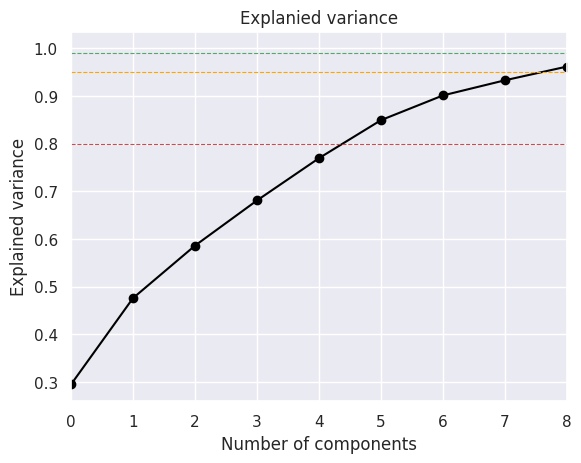

In [12]:
plt.figure()

plt.plot(pca.explained_variance_ratio_.cumsum(), marker = 'o', color='black')
plt.xlabel('Number of components')
plt.ylabel('Explained variance')
plt.axhline(y=0.99, color='g', linestyle='--', linewidth=0.8, label='y = 0.99')
plt.axhline(y=0.95, color='orange', linestyle='--', linewidth=0.8, label='y = 0.8')
plt.axhline(y=0.8, color='r', linestyle='--', linewidth=0.8, label='y = 0.8')
plt.xlim(0, 8)
# Añadir un título (opcional)
plt.title('Explanied variance')

# Mostrar el gráfico
plt.show()

In [16]:
pca = PCA(n_components = 3)

In [17]:
pca.fit(nuclei_cytoplasm_std)

PCA(n_components=3)

In [18]:
pca_result = pca.transform(nuclei_cytoplasm_std)
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2', 'PC3'])

fig = px.scatter_3d(pca_df, x='PC1', y='PC2', z='PC3',
                    title='PCA 3D Scatter Plot',
                    labels={'PC1': 'Principal Component 1',
                            'PC2': 'Principal Component 2',
                            'PC3': 'Principal Component 3'})

fig.write_html('/app/pca.html')

## K-Means

In [20]:
scores_pca = pca.transform(nuclei_cytoplasm_std)
scores_pca

array([[-2.6190412 , -3.14386743,  4.31994722],
       [-1.0280712 , -1.83061971,  5.85630227],
       [-2.44881807, -2.93925519,  4.2942707 ],
       ...,
       [ 6.65911224,  7.56607076, -0.15288972],
       [ 6.4720825 ,  8.15355759, -3.68794544],
       [10.86154476,  6.48515686, -3.14619639]])

In [28]:
wcss = []
for i in range (1,21):
    kmeans_pca = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans_pca.fit(scores_pca)
    wcss.append(kmeans_pca.inertia_)

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will chang

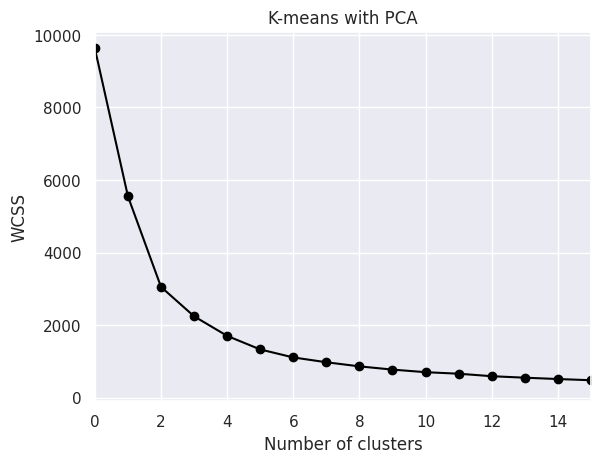

In [29]:
plt.figure()

plt.plot(wcss, marker = 'o', color='black')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('K-means with PCA')

plt.xlim(0, 15)

# Mostrar el gráfico
plt.show()

In [30]:
kmeans_pca = KMeans(n_clusters = 3, init = 'k-means++', random_state = 42)

In [31]:
kmeans_pca.fit(scores_pca)

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



KMeans(n_clusters=3, random_state=42)

In [33]:
df_segm_pca_kmeans = pd.concat([nuclei_cytoplasm.reset_index(drop = True), pd.DataFrame(scores_pca)], axis = 1)
df_segm_pca_kmeans.columns.values[-3: ] = ['C1', 'C2', 'C3']
df_segm_pca_kmeans['Segment K-means PCA'] = kmeans_pca.labels_

In [34]:
df_segm_pca_kmeans['Segment'] = df_segm_pca_kmeans['Segment K-means PCA'].map({
    0:'Primero',
    1:'Segundo',
    2:'Tercero'})

In [35]:
df_plotly = df_segm_pca_kmeans.copy()
df_plotly['Segment K-means PCA'] = df_plotly['Segment K-means PCA'].map({
    0: 'Cluster 1',
    1: 'Cluster 2',
    2: 'Cluster 3'
})

fig = px.scatter_3d(df_plotly, x='C1', y='C2', z='C3', color='Segment K-means PCA',
                    labels={'C1': 'Componente 1', 'C2': 'Componente 2', 'C3': 'Componente 3'},
                    title='PCA with K-Means Clustering')

fig.write_html('/app/pca_kmeans.html')

In [ ]:
import plotly.graph_objs as go
import plotly.express as px
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples

# Supongamos que ya has ajustado PCA y KMeans
# pca = PCA(n_components=3)
# pca_result = pca.fit_transform(nuclei_std)
# kmeans = KMeans(n_clusters=3)
# labels = kmeans.fit_predict(pca_result)
# centers = kmeans.cluster_centers_

# Crear DataFrame de PCA con etiquetas de clúster
df_plotly = df_segm_pca_kmeans.copy()
df_plotly['Segment K-means PCA'] = df_plotly['Segment K-means PCA'].map({
    0: 'Cluster 1',
    1: 'Cluster 2',
    2: 'Cluster 3'
})

# Crear DataFrame para los centroides
centers_df = pd.DataFrame(centers, columns=['C1', 'C2', 'C3'])
centers_df['Cluster'] = ['Cluster 1', 'Cluster 2', 'Cluster 3']

# Crear el gráfico 3D
fig = px.scatter_3d(df_plotly, x='C1', y='C2', z='C3', color='Segment K-means PCA',
                    labels={'C1': 'Componente 1', 'C2': 'Componente 2', 'C3': 'Componente 3'},
                    title='PCA with K-Means Clustering')

# Añadir los centroides al gráfico
fig.add_trace(go.Scatter3d(
    x=centers_df['C1'],
    y=centers_df['C2'],
    z=centers_df['C3'],
    mode='markers',
    marker=dict(size=10, color='red', symbol='cross'),
    name='Centroids'
))

# Añadir esferas simuladas alrededor de los centroides
# Usar la función `scatter_3d` para dibujar esferas "blobs" alrededor de los centroides
for i, row in centers_df.iterrows():
    # Crear un conjunto de puntos para simular una esfera alrededor del centroide
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x = row['C1'] + 0.5 * np.outer(np.cos(u), np.sin(v))
    y = row['C2'] + 0.5 * np.outer(np.sin(u), np.sin(v))
    z = row['C3'] + 0.5 * np.outer(np.ones(np.size(u)), np.cos(v))
    
    fig.add_trace(go.Scatter3d(
        x=x.flatten(),
        y=y.flatten(),
        z=z.flatten(),
        mode='markers',
        marker=dict(size=3, color='red', opacity=0.2),  # Ajusta el tamaño y la opacidad para simular blobs
        name=f'Cluster {i+1} Blob'
    ))

# Actualizar el layout
fig.update_layout(
    legend_title='Cluster',
    margin=dict(l=0, r=0, t=40, b=0)
)

# Guardar el gráfico como un archivo HTML
fig.write_html('/app/pca_kmeans_blobs.html')

## UMap

In [37]:
import umap
import plotly.express as px
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

2024-09-16 11:42:02.818971: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2024-09-16 11:42:02.819004: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [39]:
# Aplicar UMAP
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', n_components=3)
umap_result = umap_model.fit_transform(nuclei_cytoplasm_std)

In [40]:
# Crear DataFrame para UMAP
df_umap = pd.DataFrame(umap_result, columns=['UMAP1', 'UMAP2', 'UMAP3'])
# Si tienes etiquetas o clústeres, agrégales aquí, por ejemplo:
# df_umap['Cluster'] = labels  # si ya tienes etiquetas de clústeres

In [41]:
# Crear gráfico 3D si quieres explorar en 3 dimensiones (necesitas n_components=3)
umap_model_3d = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', n_components=3)
umap_result_3d = umap_model_3d.fit_transform(nuclei_cytoplasm_std)
df_umap_3d = pd.DataFrame(umap_result_3d, columns=['UMAP1', 'UMAP2', 'UMAP3'])

fig_3d = px.scatter_3d(df_umap_3d, x='UMAP1', y='UMAP2', z='UMAP3',
                      labels={'UMAP1': 'UMAP Dimension 1', 'UMAP2': 'UMAP Dimension 2', 'UMAP3': 'UMAP Dimension 3'},
                      title='UMAP Projection of Original Data (3D)')

fig_3d.write_html('/app/umap_3d.html')

## K-means

In [43]:
# Aplicar K-Means
kmeans = KMeans(n_clusters=3)  # Ajusta el número de clústeres según sea necesario
clusters = kmeans.fit_predict(umap_result_3d)

# Agregar las etiquetas de clúster al DataFrame
df_umap_3d['Cluster'] = clusters

# Visualizar con Plotly
import plotly.express as px
fig = px.scatter_3d(df_umap_3d, x='UMAP1', y='UMAP2', z='UMAP3', color='Cluster',
                    title='UMAP with K-Means Clustering')
fig.write_html('/app/umap_kmeans.html')


/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convertir la tabla en un DataFrame para visualización
df_summary = cluster_summary.T
plt.figure(figsize=(12, 6))
sns.heatmap(df_summary, cmap='viridis', annot=True, fmt='.2f', linewidths=0.5)
plt.title('Características por Cluster')
plt.show()

NameError: name 'cluster_summary' is not defined